In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('paris-arbres-clean-2023-09-10.csv')

/tmp/ipykernel_12431/3679605312.py:5: DtypeWarning: Columns (0: idbase, 1: numero) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('paris-arbres-clean-2023-09-10.csv')


In [15]:
df = df[df.libelle_francais == 'Platane'].copy()
df.info()

<class 'pandas.DataFrame'>
Index: 42588 entries, 3 to 221193
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   idbase                  42588 non-null  object 
 1   domanialite             42588 non-null  str    
 2   arrondissement          42588 non-null  str    
 3   complement_adresse      15309 non-null  str    
 4   numero                  0 non-null      str    
 5   lieu_adresse            42588 non-null  str    
 6   idemplacement           42588 non-null  str    
 7   libelle_francais        42588 non-null  str    
 8   genre                   42588 non-null  str    
 9   espece                  42584 non-null  str    
 10  variete_oucultivar      260 non-null    str    
 11  circonference_cm        42588 non-null  float64
 12  hauteur_m               42588 non-null  float64
 13  stade_de_developpement  39238 non-null  str    
 14  remarquable             41352 non-null  str    
 15  

In [16]:
df['stade_de_developpement'].value_counts()

stade_de_developpement
Adulte                 21620
Jeune (arbre)Adulte     8356
Jeune (arbre)           5916
Mature                  3346
Name: count, dtype: int64

<Axes: xlabel='stade_de_developpement', ylabel='circonference_cm'>

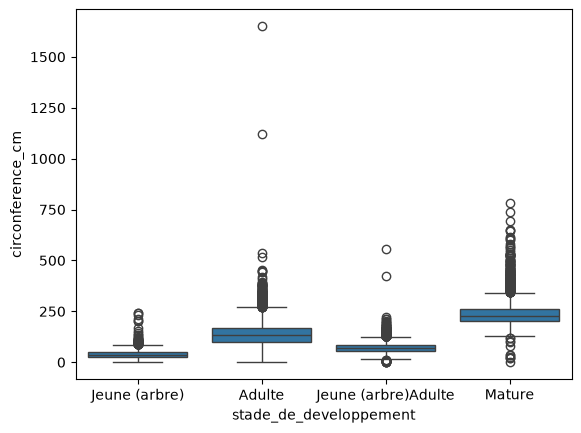

In [17]:
sns.boxplot(data = df, y="circonference_cm", x="stade_de_developpement")

<Axes: xlabel='stade_de_developpement', ylabel='hauteur_m'>

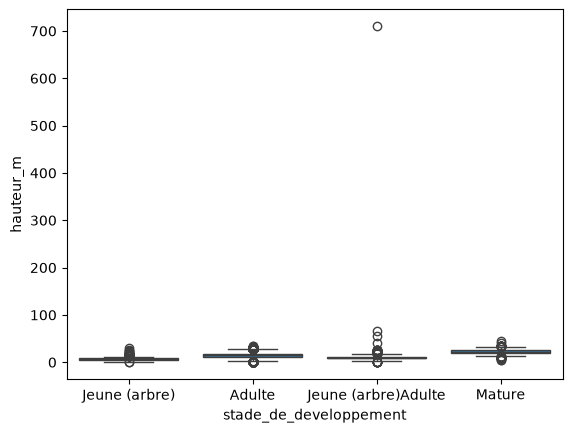

In [18]:
sns.boxplot(data = df, y="hauteur_m", x="stade_de_developpement")

In [19]:
cond = (df.stade_de_developpement.isna()) & (df.hauteur_m > 20) & (df.circonference_cm > 200)
df[cond].shape

(22, 16)

In [20]:
cond = (df.stade_de_developpement.isna()) & (df.hauteur_m < 8) & (df.circonference_cm < 50)
df[cond].shape

(2903, 16)

<Axes: xlabel='circonference_cm', ylabel='hauteur_m'>

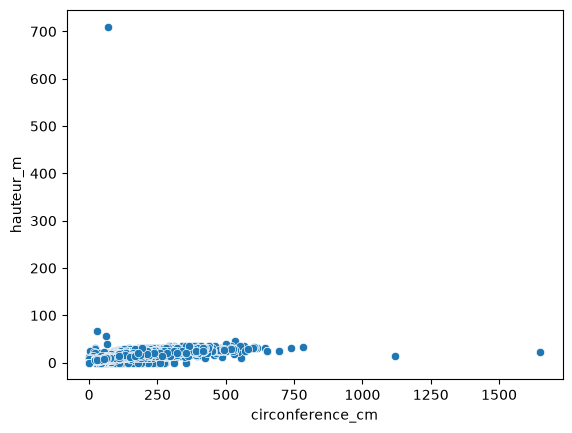

In [21]:
sns.scatterplot(x=df.circonference_cm, y=df.hauteur_m)

In [22]:
df = df[(df.circonference_cm < 1000) & (df.hauteur_m < 100)].copy()

In [23]:
from scipy import stats
df['z_circonference'] = stats.zscore(df.circonference_cm)
df['z_hauteur'] = stats.zscore(df.hauteur_m)

(array([1.597e+03, 1.100e+01, 6.000e+00, 1.800e+01, 1.600e+01, 2.020e+03,
        9.410e+02, 7.640e+02, 8.960e+02, 1.820e+02, 1.007e+03, 9.200e+02,
        1.157e+03, 2.110e+02, 1.117e+03, 1.285e+03, 1.103e+03, 1.288e+03,
        2.420e+02, 1.114e+03, 1.216e+03, 1.056e+03, 1.252e+03, 2.170e+02,
        9.770e+02, 1.213e+03, 9.320e+02, 2.150e+02, 1.111e+03, 9.640e+02,
        1.026e+03, 8.700e+02, 1.730e+02, 9.680e+02, 8.250e+02, 8.720e+02,
        7.890e+02, 1.330e+02, 8.160e+02, 7.030e+02, 7.990e+02, 1.590e+02,
        6.060e+02, 7.440e+02, 5.890e+02, 7.040e+02, 1.240e+02, 4.570e+02,
        5.770e+02, 4.550e+02, 8.600e+01, 5.390e+02, 4.010e+02, 4.240e+02,
        3.260e+02, 8.700e+01, 3.750e+02, 2.420e+02, 3.160e+02, 2.020e+02,
        6.300e+01, 2.440e+02, 1.640e+02, 1.880e+02, 6.200e+01, 1.290e+02,
        1.450e+02, 9.400e+01, 1.040e+02, 4.200e+01, 7.100e+01, 9.300e+01,
        5.100e+01, 6.400e+01, 1.200e+01, 4.900e+01, 5.600e+01, 3.400e+01,
        9.000e+00, 3.700e+01, 2.500e+0

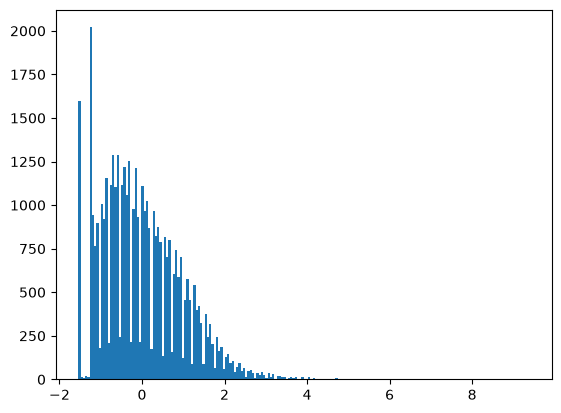

In [24]:
plt.hist(df['z_circonference'], bins=200)

(array([1.688e+03, 0.000e+00, 1.600e+01, 0.000e+00, 0.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 3.400e+01, 0.000e+00, 0.000e+00, 9.200e+01,
        0.000e+00, 0.000e+00, 4.309e+03, 0.000e+00, 0.000e+00, 1.291e+03,
        0.000e+00, 0.000e+00, 1.093e+03, 0.000e+00, 0.000e+00, 2.211e+03,
        0.000e+00, 0.000e+00, 1.013e+03, 0.000e+00, 0.000e+00, 6.126e+03,
        0.000e+00, 0.000e+00, 6.810e+02, 0.000e+00, 0.000e+00, 2.967e+03,
        0.000e+00, 0.000e+00, 9.360e+02, 0.000e+00, 0.000e+00, 1.382e+03,
        0.000e+00, 0.000e+00, 6.602e+03, 0.000e+00, 0.000e+00, 1.357e+03,
        0.000e+00, 0.000e+00, 1.050e+03, 0.000e+00, 0.000e+00, 2.251e+03,
        0.000e+00, 0.000e+00, 3.410e+02, 0.000e+00, 0.000e+00, 3.762e+03,
        0.000e+00, 0.000e+00, 1.290e+02, 0.000e+00, 0.000e+00, 7.250e+02,
        0.000e+00, 0.000e+00, 2.090e+02, 0.000e+00, 0.000e+00, 1.860e+02,
        0.000e+00, 0.000e+00, 1.339e+03, 0.000e+00, 0.000e+00, 1.450e+02,
        0.000e+00, 0.000e+00, 8.900e+0

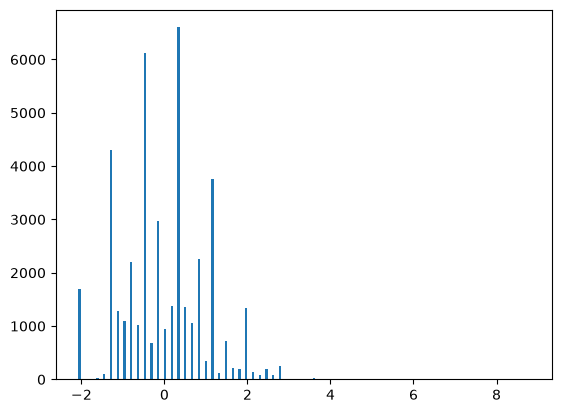

In [25]:
plt.hist(df['z_hauteur'], bins=200)

In [31]:
import numpy as np
iqr = np.quantile(df.hauteur_m, q=[0.25, 0.75])
limite_basse = iqr[0] - 1.5*(iqr[1] - iqr[0])
limite_haute = iqr[1] + 1.5*(iqr[1] - iqr[0])
print(df.loc[df['z_hauteur'] > 2, 'z_hauteur'].count())
print(df.loc[(df['z_hauteur'] < -3) | (df['z_hauteur'] > 3), 'z_hauteur'].count())
print(df.loc[(df['hauteur_m'] < limite_basse) | (df['hauteur_m'] > limite_haute), 'hauteur_m'].count())

793
33
44


In [32]:
iqr = np.quantile(df.circonference_cm, q=[0.25, 0.75])
limite_basse = iqr[0] - 1.5*(iqr[1] - iqr[0])
limite_haute = iqr[1] + 1.5*(iqr[1] - iqr[0])
print(df.loc[df['z_circonference'] > 2, 'z_circonference'].count())
print(df.loc[(df['z_circonference'] < -3) | (df['z_circonference'] > 3), 'z_circonference'].count())
print(df.loc[(df['circonference_cm'] < limite_basse) | (df['circonference_cm'] > limite_haute), 'hauteur_m'].count())

1429
349
485
